<a href="https://colab.research.google.com/github/alphthonio/My-MIT-/blob/Master/Product_db_Vector_Databases_Notebook_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><center><font size=10>Advanced Python - From Analytics to AI</center></font></h1>
<h1><center>Vector Databases - Setting up a Vector Database</center></h1>

### Setup

In [1]:
!pip install -q chromadb==0.4.22 \
                langchain==0.1.9 \
                langchain-community==0.0.32 \
                sentence-transformers==2.3.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 4.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.0/509.0 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 817.0/817.0 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.8/273.8 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.1/303.1 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 7.7 MB/s eta 0

In [2]:
from scipy.spatial.distance import cosine
import pandas as pd

from google.colab import userdata
from google.colab import drive

from langchain_core.documents import Document
from langchain_community.embeddings.sentence_transformer import SentenceTransformerEmbeddings
from langchain_community.vectorstores import Chroma


#### Importing the Embedding Model

In [3]:
embedding_model_name = 'thenlper/gte-large'

In [4]:
embedding_model = SentenceTransformerEmbeddings(model_name=embedding_model_name)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/67.9k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/619 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/712k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

## Importing Data

In [5]:
products_data = pd.read_csv("products_data.csv")

In [6]:
products_data.shape

(11565, 14)

We have 11.5k+ products and 14 columns in this dataset. Let's have a glance at the data.

In [7]:
products_data.head()

,Unnamed: 0,uniq_id,category,product_description,brand,pack_size_or_quantity,mrp,price,site_name,offers,combo_offers,stock_availibility,product_asin,image_urls
0,4,3ac3f213732512d1d11bb73ab3b1900f,Grocery & Gourmet Foods,Harvey's wafer Cream Wafer 110g. Made in India,Harveys,NaN,594,570,Amazon In,4.04%,NaN,YES,B07NFYYLF1,https://images-na.ssl-images-amazon.com/images...
1,6,ddb01f73b53ea264c0a9fcc31b1dbd72,Bath & Shower,Our handmade soaps are made with the highest g...,Lather+%26+Fizz+Bath+Boutique,NaN,9086,7269,Amazon In,20.00%,NaN,YES,B06XSRZV65,https://images-na.ssl-images-amazon.com/images...
2,7,516c5986d5dc20efaa37a58cbdea755a,Bath & Shower,Mydio 2 Pack Waterproof Women Shower Caps Bath...,Mydio,49.9 g,1659,1659,Amazon In,0%,NaN,YES,B074FVJN7D,https://images-na.ssl-images-amazon.com/images...
3,8,fc4d5d08dcad5e10f3408e89990065a0,Grocery & Gourmet Foods,Pistachios are small in appearance and are enc...,FOODSTUDIO,399 Grams,760,660,Amazon In,13.16%,NaN,YES,B07Y3PTX42,https://images-na.ssl-images-amazon.com/images...
4,9,306bc2d444aa62cd53eb46fdbfd5c6f5,Grocery & Gourmet Foods,GLUTEN FREE KHAKHRAS. LIGHT HEALTHY AND ROASTE...,Dr Gluten,NaN,279,279,Amazon In,0%,NaN,YES,B07Y4SSRR1,https://images-na.ssl-images-amazon.com/images...


We can see that product_description is the most relevant detail for us for this use-case. Additionally, we could add details from other columns like weight and price into the product description. This will create embeddings with more details about the product.

In [8]:
products_data.product_description[3]

'Pistachios are small in appearance and are enclosed in hard, nutty shells. Once you break open these shells, you can find the actual pistachio nuts which are light-green or light-brown. A common way of eating pistachios is by roasting or salting them and is often eaten as snacks. We at Food Studio strive to provide our customers with the most premium quality of pistachios by ensuring a bigger shell size along with a brighter shell color, which isn’t easily available in the market.'

Let's drop any duplicates products that may be present in the dataset.

In [9]:
products_data.drop_duplicates(subset = "uniq_id",inplace= True)

In [10]:
products_data.shape

(11565, 14)

There were no duplicate products in the dataset. Good!

In [11]:
products_data["product_description"] = products_data["product_description"] + " from the company " + products_data["brand"] + " at the price " + products_data["price"] + " with a discount of " + products_data["offers"]

In [12]:
products_data.product_description[3]

'Pistachios are small in appearance and are enclosed in hard, nutty shells. Once you break open these shells, you can find the actual pistachio nuts which are light-green or light-brown. A common way of eating pistachios is by roasting or salting them and is often eaten as snacks. We at Food Studio strive to provide our customers with the most premium quality of pistachios by ensuring a bigger shell size along with a brighter shell color, which isn’t easily available in the market. from the company FOODSTUDIO at the price 660 with a discount of 13.16%'

That is a better description of the product.

Let's create documents from the product description. Let's also add a little meta-deta so that if we quickly wish to show the meta-data in search resutls or if we want to do a pre-filter, it will come in handy

In [13]:
docs = [Document(page_content = doc, metadata = {"id":id, "price": price})for doc, id, price in zip(products_data['product_description'],products_data['uniq_id'],products_data['price'])
                 ]

In [14]:
docs

[Document(page_content="Harvey's wafer Cream Wafer 110g. Made in India from the company Harveys at the price 570 with a discount of 4.04%", metadata={'id': '3ac3f213732512d1d11bb73ab3b1900f', 'price': '570'}),
 Document(page_content='Our handmade soaps are made with the highest grade glycerin, top grade essential oils, fragrance oils and natural botanicals. Lather up & enjoy! Who knew soap could be so much fun from the company Lather+%26+Fizz+Bath+Boutique at the price 7269 with a discount of 20.00%', metadata={'id': 'ddb01f73b53ea264c0a9fcc31b1dbd72', 'price': '7269'}),
 Document(page_content='Mydio 2 Pack Waterproof Women Shower Caps Bath Cap,Double Layer Satin Lined Shower Cap for Women from the company Mydio at the price 1659 with a discount of 0%', metadata={'id': '516c5986d5dc20efaa37a58cbdea755a', 'price': '1659'}),
 Document(page_content='Pistachios are small in appearance and are enclosed in hard, nutty shells. Once you break open these shells, you can find the actual pistachi

# Indexing to Chroma

In [15]:
products = Chroma.from_documents(
    docs,
    embedding_model,
    collection_name="product_embeddings",
    persist_directory='./products_db'
)

Let's do a test query!

In [16]:
query = "rose scented perfume" # If there are no rose scented perfumes, it should suggest other flowery or fruity flavours before moving to men perfumes.

In [17]:
docs = products.similarity_search(query, k=5)

In [18]:
for i, doc in enumerate(docs):
    print(f"Retrieved chunk {i+1}: \n")
    print(doc.page_content.replace('\t', ' '))
    print('\n')

Retrieved chunk 1: 

Enlighten your mood with the instant sense gratification that the fragrance of Rose endows. Embellis the sentiment in the care of Glycerin. Enjoy your own floral paradise everyday from the company Generic at the price 56 with a discount of 13.85%


Retrieved chunk 2: 

Odour description: - rose (Blended with some top citrus notes to boost the impact of fragrance and provide a pleasant impact). from the company Girish And Company at the price 100 with a discount of 0%


Retrieved chunk 3: 

Real Rose Various facets of the floral world are infused to bring alive this sensuously charming fragrance. Top Notes:Green tea, Fresh Flowers. Heart Notes:Rose, Violet leaves. Base Notes:Rose, amber. from the company Arochem at the price 83 with a discount of 47.80%


Retrieved chunk 4: 

Enlighten your mood with the instant sense gratification that the fragrance of Rose endows. Embellish the sentiment in the care of Glycerin. Enjoy your own floral paradise everyday from the com

In [24]:
query2 = "My skin has gone dry provide moisturizer" # If there are no rose scented perfumes, it should suggest other flowery or fruity flavours before moving to men perfumes.


In [27]:
docs = products.similarity_search(query2, k=6)

In [28]:
for i, doc in enumerate(docs):
    print(f"Retrieved chunk {i+1}: \n")
    print(doc.page_content.replace('\t', ' '))
    print('\n')

Retrieved chunk 1: 

A powerful, all natural & nutrient-rich face creamcontains sweet almond oil, rich in essential fatty acids that deliver long-lasting hydrationprotects skin's natural moisture from damaging environmental influencesblended with beeswax to form a breathable layer that prevents moisture lossskin appears suppler, sleeker, stronger &fortableperfect for dry & very dry skin from the company Weleda at the price 6916 with a discount of 20.47%


Retrieved chunk 2: 

Aveeno Daily Moisturizing Lotion, unlike ordinary lotions, contains natural oatmeal blended with rich emollients to moisturize your skin for a full 24 hours. The unique oatmeal formula of Aveeno also helps prevent and protect dry skin providing temporary relief of the scaling and chapping associated with dry skin. This naturally nourishing, nongreasy formula absorbs quickly, is noncomedogenic (won't clog pores), and contains no added fragrance. Aveeno Daily Moisturizing Lotion leaves your skin soft, smooth and nat

In [32]:
query = 'flaxseeds are considered one of the most powerful plants on the planet. Rich in heart loving omega 3 essential fatty acids, lignans and both soluble and insoluble fibre, flaxseed bestows health benefits like no other.'

In [33]:
docs = products.similarity_search_with_relevance_scores(query2, k=5)

In [36]:
docs

[(Document(page_content="A powerful, all natural & nutrient-rich face creamcontains sweet almond oil, rich in essential fatty acids that deliver long-lasting hydrationprotects skin's natural moisture from damaging environmental influencesblended with beeswax to form a breathable layer that prevents moisture lossskin appears suppler, sleeker, stronger &fortableperfect for dry & very dry skin from the company Weleda at the price 6916 with a discount of 20.47%", metadata={'id': 'bf4899ed388f351957fbaec74ded6155', 'price': '6916'}),
  0.8328479063457502),
 (Document(page_content="Aveeno Daily Moisturizing Lotion, unlike ordinary lotions, contains natural oatmeal blended with rich emollients to moisturize your skin for a full 24 hours. The unique oatmeal formula of Aveeno also helps prevent and protect dry skin providing temporary relief of the scaling and chapping associated with dry skin. This naturally nourishing, nongreasy formula absorbs quickly, is noncomedogenic (won't clog pores), a

In [35]:
for i, (doc, score) in enumerate(docs): # Unpack the tuple into doc and score
    print(f"Retrieved chunk {i+1} (Score: {score:.4f}): \n") # Print the score
    print(doc.page_content.replace('\t', ' ')) # Access page_content from the Document object
    print('\n')


Retrieved chunk 1 (Score: 0.8328): 

A powerful, all natural & nutrient-rich face creamcontains sweet almond oil, rich in essential fatty acids that deliver long-lasting hydrationprotects skin's natural moisture from damaging environmental influencesblended with beeswax to form a breathable layer that prevents moisture lossskin appears suppler, sleeker, stronger &fortableperfect for dry & very dry skin from the company Weleda at the price 6916 with a discount of 20.47%


Retrieved chunk 2 (Score: 0.8301): 

Aveeno Daily Moisturizing Lotion, unlike ordinary lotions, contains natural oatmeal blended with rich emollients to moisturize your skin for a full 24 hours. The unique oatmeal formula of Aveeno also helps prevent and protect dry skin providing temporary relief of the scaling and chapping associated with dry skin. This naturally nourishing, nongreasy formula absorbs quickly, is noncomedogenic (won't clog pores), and contains no added fragrance. Aveeno Daily Moisturizing Lotion leave

In [37]:
count = 0
for i, (doc, r) in enumerate(docs):
    if count < 5 and r < 0.85 and r > 0.80: # r is inversely proportional to cosine_distance, so higher score means higher similarity.
      # We are oly selecting products between similarity scores of 0.85 and 0.80. This way products that are related but not the same product might surface.
      # The numbers are chosen pragmatically and there is no formula to come up with them
      count += 1 # To get only 5 results
      print(f"Retrieved chunk {i+1}: \n")
      print(doc.page_content.replace('\t', ' '))
      print(doc.metadata)
      print('\n')


Retrieved chunk 1: 

A powerful, all natural & nutrient-rich face creamcontains sweet almond oil, rich in essential fatty acids that deliver long-lasting hydrationprotects skin's natural moisture from damaging environmental influencesblended with beeswax to form a breathable layer that prevents moisture lossskin appears suppler, sleeker, stronger &fortableperfect for dry & very dry skin from the company Weleda at the price 6916 with a discount of 20.47%
{'id': 'bf4899ed388f351957fbaec74ded6155', 'price': '6916'}


Retrieved chunk 2: 

Aveeno Daily Moisturizing Lotion, unlike ordinary lotions, contains natural oatmeal blended with rich emollients to moisturize your skin for a full 24 hours. The unique oatmeal formula of Aveeno also helps prevent and protect dry skin providing temporary relief of the scaling and chapping associated with dry skin. This naturally nourishing, nongreasy formula absorbs quickly, is noncomedogenic (won't clog pores), and contains no added fragrance. Aveeno Dai

In [38]:
count

5

# Save Database State to Google Drive

Using a GPU to create an index is the most compute intensive portion of operating a vector database. While we have persisted the database to the local Colab instance in the previous section, this folder is lost once the notebook is disconnected. To avoid losing data, we can copy the database state from the notebook to Google Drive for later reuse.

Provide Gdrive access to colab

In [39]:
drive.mount('/content/drive')

Mounted at /content/drive


In [40]:
!cp -r products_db /content/drive/MyDrive

The above code saves the database state to Google Drive (within My Drive).

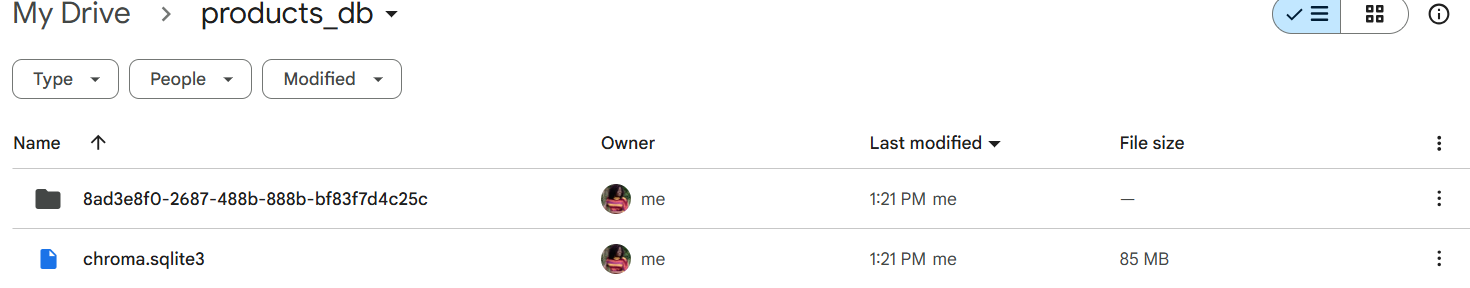

Let's check the persisted DB once before we move on to the next task.

In [41]:
persisted_vectordb_location = '/content/drive/MyDrive/products_db'

In [42]:
vectorstore_persisted = Chroma(
    collection_name="product_embeddings",
    persist_directory=persisted_vectordb_location,
    embedding_function=embedding_model
)

That was super quick! Let's do a quick check.

In [43]:
docs = vectorstore_persisted.similarity_search(query, k=5)

In [44]:
for i, doc in enumerate(docs):
    print(f"Retrieved chunk {i+1}: \n")
    print(doc.page_content.replace('\t', ' '))
    print('\n')

Retrieved chunk 1: 

Flaxseeds are considered one of the most powerful plant foods on the planet. Rich in heart loving omega 3 essential fatty acids, lignans and both soluble and insoluble fibre, flaxseed bestows health benefits like no other. from the company Organo Nutri at the price 221 with a discount of 35.00%


Retrieved chunk 2: 

Flaxseeds are considered one of the most powerful plant foods on the planet. Rich in heart loving omega 3 essential fatty acids, lignans and both soluble and insoluble fibre, flaxseed bestows health benefits like no other. from the company Organo Nutri at the price 130 with a discount of 35.00%


Retrieved chunk 3: 

Kitchen & Health brings to you the world’s first cultivated superfood. Flax seeds help improve digestion, improve skin health, reduce sugar cravings and promote weight management. Flax seeds, sometimes called linseeds, are small, brown, tan or golden-coloured seeds that are the richest sources of a plant-based omega-3 fatty acids, called a

We can now run the similarity search as before, but the database is hosted and streamed from Google Drive.

We can now go ahead and switch to a Non-GPU isntance and perfrom the later stages of the project. Even in industry, similar strategy can be used where we use GPU instances to create vectorDB and persist in a safe location and later use CPU instances for everyday search queries from the website.